In [113]:
import os
import sys
import glob
import numpy as np
import  scipy.optimize as op
import matplotlib.pyplot as plt
import urllib.request
from astropy.io import fits as fits
from astropy.table import Table
import pandas as pd
import urllib.request
import requests
import astropy.units as u
import astropy
from astropy.coordinates import SkyCoord
from pathlib import Path
from numpy import savetxt
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
from dustmaps.sfd import SFDQuery
import astropy.cosmology.units as cu
from astropy.coordinates import match_coordinates_sky
import io
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import matplotlib.image as mpimg

## SDSS galaxies

/home/hollman/DataHII/gal_info_dr7_v5_2.fit.gz already exist


(array([2.63440e+04, 1.88535e+05, 1.42359e+05, 1.52329e+05, 1.39796e+05,
        1.14497e+05, 8.54860e+04, 6.70230e+04, 1.04170e+04, 3.30000e+01]),
 array([-16.67872238,  -6.58381319,   3.51109624,  13.60600567,
         23.70091438,  33.79582214,  43.89073181,  53.98564148,
         64.08055115,  74.17546082,  84.27037048]),
 <BarContainer object of 10 artists>)

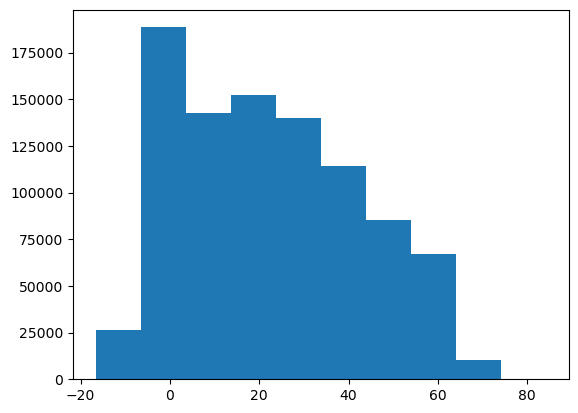

In [65]:
home = os.path.expanduser("~") + '/'
DATA_URL="http://das.sdss.org/spectro/ss_tar_26/"
file="gal_info_dr7_v5_2.fit.gz"
local_file = os.path.join(home + "DataHII/",file)

if not os.path.exists(local_file):
        print("downloading DR7 quasar dataset from %s to %s"
              % (DATA_URL+file, local_file ))
        tmp = urllib.request.urlretrieve(DATA_URL+local_file, local_file)
        print ("Downloaded file"+local_file)
else:
    print("%s already exist"%(local_file))

catalog=Table.read(local_file)
w=((catalog['RA']!=catalog['DEC']) & (catalog['RA']>0) & ((catalog['DEC']>=-90) | (catalog['DEC']<=90)) & (catalog['Z']>=0) & ( catalog['Z'] != float('nan') ) & ( catalog['DEC'] != float('nan') ) & ( catalog['RA'] != float('nan') ))
reduced_cat=catalog[w]
#reduced_cat
plt.hist(reduced_cat['DEC'])

In [66]:
NED = pd.read_csv('NED_Chavez2012.csv', sep=",", header=0)
NED.columns
NED['Redshift (z)'][127] = 0.009486
NED

/tmp/ipykernel_11582/832320834.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  NED['Redshift (z)'][127] = 0.009486
/tmp/ipykernel_11582/832320834.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

,No.,Object Name,RA,Dec,Object Type,Redshift (z)
0,1,UM 199,1.737614,0.857181,G,0.073682
1,2,UM 282,12.947112,0.161124,G,0.037556
2,3,UM 336,23.436174,0.953078,G,0.019236
3,4,MRK 0627,131.643397,36.438978,G,0.010634
4,5,SBS 0934+546,144.556301,54.473618,G,0.102102
...,...,...,...,...,...,...
123,124,WISEA J101136.07+263027.5,152.900317,26.507660,G,0.054666
124,125,WISEA J162152.58+151855.9,245.469098,15.315537,G,0.034341
125,126,WISEA J090506.84+223834.7,136.278600,22.642759,G,0.125548
126,127,WISEA J094000.50+203122.7,145.002109,20.522973,G,0.044799


In [67]:
SIMBAD = pd.read_csv('SIMBAD_Chavez2012.csv', sep=";", header=0)
SIMBAD.columns

Index([' # ', ' obj tags ', 'obj count', '    raw id    ',
       '            identifier             ', 'typ',
       '      coord1 (FK5,J2000/2000)      ', '  redshift  '],
      dtype='object')

In [69]:
data_coor = SIMBAD['      coord1 (FK5,J2000/2000)      ']

ra = np.array([float(str(a).split()[0]) for a in data_coor])
dec = np.array([float(str(a).split()[1]) for a in data_coor])

SIMBAD['ra'] = ra
SIMBAD['dec'] = dec

SIMBAD

,#,obj tags,obj count,raw id,identifier,typ,"coord1 (FK5,J2000/2000)",redshift,ra,dec
0,1,d,3,J000657+005125,SHOC 2,Sy1,001.7374419936384 +00.8573176472766,0.07370,1.737442,0.857318
1,2,d,3,J001647-104742,LEDA 973666,G,004.199012 -10.795065,0.02324,4.199012,-10.795065
2,3,d,3,J002339-094848,6dFGS gJ002339.6-094848,Sy1,005.915047 -09.813533,0.05305,5.915047,-9.813533
3,4,d,3,J002425+140410,LEDA 101427,H2G,006.1081153099142 +14.0696497224747,0.01423,6.108115,14.069650
4,5,d,3,J003218+150014,SHOC 22,H2G,008.0776246735898 +15.0039207329153,0.01795,8.077625,15.003921
...,...,...,...,...,...,...,...,...,...,...
132,133,d,3,J230117+135230,SDSS J230117.64+135230.2,G,345.323545 +13.875071,0.02456,345.323545,13.875071
133,134,d,3,J230123+133314,[ITS2007] 52263-742-179,H2G,345.348307 +13.554096,0.03029,345.348307,13.554096
134,135,d,3,J230703+011311,SHOC 595,Sy1,346.7656830052835 +01.2197848644810,0.12577,346.765683,1.219785
135,136,d,3,J231442+010621,[VV2003c] J231442.1+010620,Sy1,348.675646 +01.105846,0.03420,348.675646,1.105846


In [70]:
### Mathc between NED and SIMBAD
NED_astro = Table.from_pandas(NED)
#NED_astro = NED_astro[NED_astro['Object Name']=='WISEA J192757.99-413431.8']
SIMBAD_astro = Table.from_pandas(SIMBAD)
SIMBAD_astro = SIMBAD_astro[SIMBAD_astro['  redshift  ']>=0]


In [71]:

ra1 = np.array(SIMBAD_astro['ra'])
dec1 = np.array(SIMBAD_astro['dec'])
D1 = np.array(SIMBAD_astro['  redshift  '])


ra2 = np.array(NED_astro['RA'])
dec2 = np.array(NED_astro['Dec'])
D2 = np.array(NED_astro['Redshift (z)'])




SIMBAD_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree,
                      distance = D1 * u.kpc)


NED_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree,
                    distance = D2 * u.kpc)



idx, d2d, d3d = NED_cat.match_to_catalog_sky(SIMBAD_cat)

In [72]:
len(idx)
#idx

new_SIMBAD = SIMBAD_astro[idx]
len(np.unique(new_SIMBAD['            identifier             ']))

128

In [73]:
ra1 = np.array(reduced_cat['RA'])
dec1 = np.array(reduced_cat['DEC'])
D1 = np.array(reduced_cat['Z'])



ra2 = np.array(new_SIMBAD['ra'])
dec2 = np.array(new_SIMBAD['dec'])
D2 = np.array(new_SIMBAD['  redshift  '])




SDSS_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree,
                      distance = D1 * u.kpc)


SIMBADmod_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree,
                    distance = D2 * u.kpc)



idx, d2d, d3d = SIMBADmod_cat.match_to_catalog_sky(SDSS_cat)





In [74]:
len(idx)

128

In [ ]:
# Last check

Obj = 0





#pos = coords.SkyCoord(ra = NED_astro['RA'][2] * u.degree,
                      #dec = NED_astro['Dec'][2] * u.degree,
                      #frame='icrs')
#xid = SDSS.query_region(pos, radius='0.9 arcsec', spectro=True)


#for n in range(len(idx)):
#for n in range(20):
#    plateid = str(reduced_cat['PLATEID'][idx[n]])
#    mjd = str(reduced_cat['MJD'][idx[n]])
#    fiberid = str(reduced_cat['FIBERID'][idx[n]])
#    print(plateid,mjd,fiberid)


#xid

ra,dec,objid,run,rerun,camcol,field,z,plate,mjd,fiberID,specobjid,run2d
float64,float64,uint64,int64,int64,int64,int64,float64,int64,int64,int64,uint64,int64
23.4359526850297,0.953121139115853,1237663785281388704,4263,301,6,272,0.01923561,697,52226,571,784909227700283392,26
23.4359526850297,0.953121139115853,1237663785281388704,4263,301,6,272,0.01924106,400,51820,441,450481214428571648,26


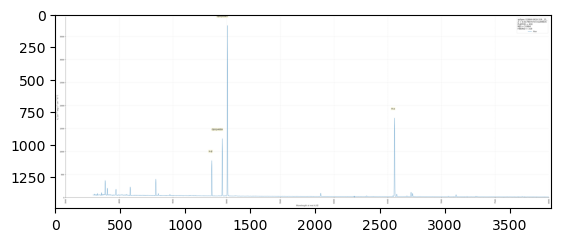

In [118]:
PATH_img = home + "DataHII/HIIGs/Spectra_plots/"
PNG_list = os.listdir(home + "DataHII/HIIGs/Spectra_plots/")


img = mpimg.imread(PATH_img + PNG_list[0])
plt.imshow(img)
plt.show()




In [108]:
plateid = str(reduced_cat['PLATEID'][idx[2]])
mjd = str(reduced_cat['MJD'][idx[2]])
fiberid = str(reduced_cat['FIBERID'][idx[2]])
print(plateid,mjd,fiberid)

400 51820 441


In [75]:
FOLDER = ['1d_23','1d_25','1d_26']
PLATE = '0266'
URL = "https://data.sdss.org/sas/dr7/das2/spectro/"

In [76]:
def check_link(path): # Function that takes care of seeing if the file exists on the web or not
    r = requests.head(path)
    status = r.status_code == requests.codes.ok
    if (status == True):
        return True
    else:
        return False

In [96]:
download_list = []
for n in range(len(idx)):
#for n in range(20):
    plateid = str(reduced_cat['PLATEID'][idx[n]])
    mjd = str(reduced_cat['MJD'][idx[n]])
    fiberid = str(reduced_cat['FIBERID'][idx[n]])
    

    if (len(plateid)<4) or (len(mjd)<5) or (len(fiberid)<3):
        if (len(plateid)<4):
            for x in range(4-len(plateid)):
                plateid = '0' + plateid
        if (len(mjd)<5):
            for y in range(5-len(mjd)):
                mjd = '0' + mjd
        if (len(fiberid)<3):
            for z in range(3-len(fiberid)):
                fiberid = '0' + fiberid
    #print(plateid,mjd,fiberid)

    pre_link = URL + FOLDER[0] + '/' + plateid +"/1d/spSpec" + '-' + mjd + '-' + plateid + '-' + fiberid + '.fit'

    if check_link(pre_link)==False:
        pre_link = URL + FOLDER[1] + '/' + plateid +"/1d/spSpec" + '-' + mjd + '-' + plateid + '-' + fiberid + '.fit'
        if check_link(pre_link)==False:
            pre_link = URL + FOLDER[2] + '/' + plateid +"/1d/spSpec" + '-' + mjd + '-' + plateid + '-' + fiberid + '.fit'
            if check_link(pre_link)==False:
                download_list.append('Not Found')
            else:
                download_list.append(pre_link)
        else:
            download_list.append(pre_link)
    else:
        download_list.append(pre_link)

download_list


['https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0388/1d/spSpec-51793-0388-457.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0691/1d/spSpec-52199-0691-636.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0400/1d/spSpec-51820-0400-441.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0934/1d/spSpec-52672-0934-369.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0556/1d/spSpec-51991-0556-224.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0284/1d/spSpec-51662-0284-277.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0341/1d/spSpec-51690-0341-606.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_25/2689/1d/spSpec-54149-2689-190.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/0384/1d/spSpec-51821-0384-281.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_25/2426/1d/spSpec-53795-2426-015.fit',
 'https://data.sdss.org/sas/dr7/das2/spectro/1d_23/1216/1d/spSpec-52709-1216-619.fit',
 'https://data.sdss.org/sas/dr7/das2/spectr

In [99]:
idx

array([ 57041, 205064,  64753, 307155, 144180,  10595,  38532, 889363,
        54582, 817872, 401848, 687793,  35824, 729084, 830892, 677087,
       676733, 536800, 688441, 919379, 915909, 889445, 339551, 889443,
       275290, 237819,  71492, 141170, 113090, 187769, 620110, 309988,
       292141, 230078,  80321, 545424, 337865, 580635, 605940, 118700,
       111211,  77688,   1341,   5447, 188486, 190901, 196271, 182235,
       181708, 106391,  53728, 193512,  87203, 196233,  99384,  99845,
       100696, 101146, 104029,  93279,  95952, 107195, 109263,  26405,
       181046, 181131,  53386, 181779, 152687, 153845, 194461, 221618,
       350886, 338615, 387298, 392325, 413067, 431182, 112525, 150398,
       198880, 121129, 121404,  50495, 151492, 147622, 146622, 146670,
       224241, 224657, 224641, 223761, 278138, 277103, 328086, 416662,
       532702, 531653, 539917, 603896, 609962, 603887, 666060, 661354,
       605570, 665430, 671418, 667766, 676096, 739280,  10194, 120227,
      

In [102]:
len(np.unique(idx))

128

In [100]:
reduced_cat[57041]

PLATEID,MJD,FIBERID,PHOTOID,RA,DEC,PLUG_MAG,PRIMTARGET,SECTARGET,TARGETTYPE,SPECTROTYPE,SUBCLASS,Z,Z_ERR,Z_WARNING,V_DISP,V_DISP_ERR,SN_MEDIAN,E_BV_SFD,ZTWEAK,ZTWEAK_ERR,SPECTRO_MAG,KCOR_MAG,KCOR_MODEL_MAG,RELEASE
int16,int32,int16,int16[5],float32,float32,float32[5],int16,int16,bytes19,bytes6,bytes21,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32[3],float32[3],float32[5],bytes12
388,51793,457,125 .. 89,1.7376115,0.8572106,19.8516 .. 19.1226,4,0,QSO,GALAXY,STARBURST,0.07368165,4.4130834e-06,0,0.0,21.396189,7.8278704,0.03703327,0.0,0.0,18.522682 .. 18.230062,18.452908 .. 18.825542,0.0 .. 0.0,dr123


In [101]:
fits_folder = '/DataHII/HIIGs/FITS/'

if (os.path.exists(home + fits_folder) == True):
    print('Folder for spec set saving already created \n')
else:
    print(f'Folder for spec set saveing created ({home+fits_folder}) \n')
    os.mkdir(home+fits_folder)

for f in range(len(download_list)):
    print(f"({f+1}/{len(download_list)}) Downloading {download_list[f][-25:]} ...")
    direc = home + fits_folder + download_list[f][-25:]
    DOWNLOAD = urllib.request.urlretrieve(download_list[f], direc)

Folder for spec set saving already created 

(1/128) Downloading spSpec-51793-0388-457.fit ...
(2/128) Downloading spSpec-52199-0691-636.fit ...
(3/128) Downloading spSpec-51820-0400-441.fit ...
(4/128) Downloading spSpec-52672-0934-369.fit ...
(5/128) Downloading spSpec-51991-0556-224.fit ...
(6/128) Downloading spSpec-51662-0284-277.fit ...
(7/128) Downloading spSpec-51690-0341-606.fit ...
(8/128) Downloading spSpec-54149-2689-190.fit ...
(9/128) Downloading spSpec-51821-0384-281.fit ...
(10/128) Downloading spSpec-53795-2426-015.fit ...
(11/128) Downloading spSpec-52709-1216-619.fit ...
(12/128) Downloading spSpec-53463-1981-438.fit ...
(13/128) Downloading spSpec-51997-0337-097.fit ...
(14/128) Downloading spSpec-53534-2112-557.fit ...
(15/128) Downloading spSpec-53857-2489-123.fit ...
(16/128) Downloading spSpec-53431-1947-448.fit ...
(17/128) Downloading spSpec-53432-1946-609.fit ...
(18/128) Downloading spSpec-52992-1594-563.fit ...
(19/128) Downloading spSpec-53442-1983-308.fit

In [21]:
Spec = fits.open(home + fits_folder + 'spSpec-52263-0742-161.fit')

In [22]:
def spec_plotter(name,RL=4000,LL=7000):
    local_dirspc="/home/hollman/DataHII/HIIGalaxy_Spectra(Chavez2012)/"
    spc = os.path.join(local_dirspc,name)  
    file = fits.open(spc)
    DATA = file[0].data
    zz = file[0].header['Z']
    RA = file[0].header['RA']
    DEC = file[0].header['DEC']
    c = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs')
    c.galactic
    sfd = SFDQuery()
    ebv01 = sfd(c.galactic)
    flux = DATA[0]
    wav00 = file[0].header['COEFF0']
    wavdiff = file[0].header['COEFF1']
    waveair = 10**(wav00 + wavdiff*np.arange(len(flux)))
    waveobs = waveair/(1.0+2.735182E-4+131.4182/(waveair)**2 +2.76249E8/(waveair)**4)
    file.close()
    wave = waveobs/(1.0+zz)
    fluxUnred = pyasl.unred(wave, flux, ebv=ebv01, R_V=3.1)
    flux_final = fluxUnred*(1.0+zz)**3
    wave_in = int(wave[2])             #initial wavelength
    wave_fin = int(wave[len(wave)-2])  #final wavelength
    wave_new = np.arange(wave_in, wave_fin, 1)
    flux_interpolate = interp1d(wave, flux_final, kind='quadratic')
    flux_starlight = flux_interpolate(wave_new)
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.bottom'] = True
    plt.figure(figsize=(20,8),dpi=70)
    plt.plot(wave,flux_final,label = 'Flux',lw=0.7, color ='#1C448E')
    plt.ylabel(r"$F_{\lambda}\ \left[ 10^{-17}\ {\rm erg\ s}^{-1}\ {\rm cm}^{-2}\ \AA^{-1} \right]$", style = 'oblique', family = 'serif', size = 25)
    plt.xlabel('Wavelength [$\AA$]', style = 'oblique', family = 'serif', size = 25)
    plt.yticks(fontsize = 15)
    plt.xticks(fontsize = 15)
    plot_lim = [RL,LL]
    plt.xlim(plot_lim)
    plt.ylim(0,max(flux)+15)
    plt.grid(True, which="both", ls=":", color = 'gray', linewidth = 0.5)
    txt_prop = {'style' : 'oblique', 'family' : 'serif', 'size' :15}       
    plt.legend(title = f'z = {round((zz),3)}', prop = txt_prop, loc= 'upper right')
    plt.show()


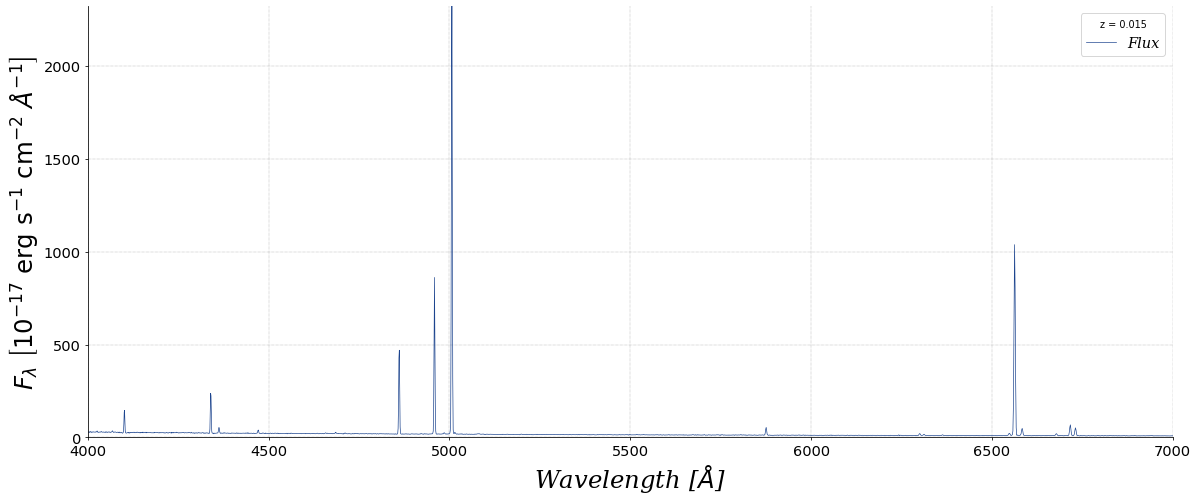

In [24]:
spec_plotter('spSpec-52992-1594-563.fit')

## GEHRs

In [13]:
#CALIFA
home = os.path.expanduser("~") + '/'
file="CALIFA_Mother_Sample.dat"
local_file = os.path.join(home + "DataHII/",file)
CALIFA = pd.read_csv(local_file,header = 0,  sep='\s+')
CALIFA.columns

Index(['NAME', 'RA', 'DEC', 'Redshift', 'r_SDSS'], dtype='object')

In [81]:
file="SampleHIIG.xlsx"
local_file = os.path.join(home + "DataHII/",file)
GEHRs = pd.read_excel(local_file,header = 0)
GEHRs['DEC'][55] = coor_x_astropy('-00:22:08.66')
GEHRs['DEC'][56] = coor_x_astropy('-00:23:01.34')
GEHRs['DEC'][57] = coor_x_astropy('-00:22:26.08')
GEHRs.columns

/tmp/ipykernel_10417/742261473.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  GEHRs['DEC'][55] = coor_x_astropy('-00:22:08.66')
/tmp/ipykernel_10417/742261473.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

Index(['Unnamed: 0', 'NOMBRE', 'RA', 'DEC'], dtype='object')

In [57]:
def coor_x_astropy(v): 

    fmt = [['h','m','s'],['d','m','s']]


    if ('+' in v) or ('-' in v):
        F = v.partition(':')[0] + fmt[1][0]
        S = (v.partition(':')[2]).partition(':')[0] + fmt[1][1]
        T = (v.partition(':')[2]).partition(':')[2] + fmt[1][2]
        
        RA = '00h00m00s'
        DEC = F+S+T
        #print(RA,DEC)
        sky_coord = SkyCoord(ra=RA, dec=DEC, unit=(u.hourangle, u.deg))
        decimal_dec = sky_coord.dec.deg

        return decimal_dec
    else:
        F = v.partition(':')[0] + fmt[0][0]
        S = (v.partition(':')[2]).partition(':')[0] + fmt[0][1]
        T = (v.partition(':')[2]).partition(':')[2] + fmt[0][2]
        
        RA = F+S+T
        DEC = '00d00m00s'
        #print(RA,DEC)
        sky_coord = SkyCoord(ra=RA, dec=DEC, unit=(u.hourangle, u.deg))
        decimal_ra = sky_coord.ra.deg

        return decimal_ra



RA_CALIFA = CALIFA['RA']
DEC_CALIFA = CALIFA['DEC']

CALIFA['RA_deg'] = [coor_x_astropy(i) for i in RA_CALIFA]
CALIFA['DEC_deg'] = [coor_x_astropy(i) for i in DEC_CALIFA]


In [143]:
ra1 = np.array(CALIFA['RA_deg'])
dec1 = np.array(CALIFA['DEC_deg'])


ra2 = np.array(GEHRs['RA'])
dec2 = np.array(GEHRs['DEC'])




CALIFA_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree)


GEHRs_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree)



idx, d2d, d3d = GEHRs_cat.match_to_catalog_sky(CALIFA_cat)

In [160]:
max_sep = 1.0 * u.arcsec
sep_constraint = d2d < max_sep
GEHRs_matches = GEHRs_cat[sep_constraint]
CALIFA_matches = CALIFA_cat[idx[sep_constraint]]

In [161]:
CALIFA_matches

<SkyCoord (ICRS): (ra, dec) in deg
    []>

In [162]:
GEHRs_matches

<SkyCoord (ICRS): (ra, dec) in deg
    []>

In [163]:
CALIFA_names = np.unique(CALIFA['NAME'])
GEHRs_names = ['MESSIER106','MESSIER066','MESSIER096','NGC1073','NGC2541','NGC3184','NGC3198','NGC3319','NGC3370','NGC4414','NGC4725',
               'NGC1073','NGC2500','NGC4214','NGC4496','NGC4535','NGC4536', 'NGC5204', 'NGC5584','UGC08091','UGC09128']
Alt = ['NGC4258','UGC07353','VV448','CGCG243-067',
       'NGC3627','UGC06346','ARP016','ARP317NED02',
       'NGC3368','UGC05882','CGCG066-013','CGCG1044.1+1205',
       'UGC02210','CGCG389-002','CGCG0241.1+0110','MCG+00-08-001',
        'UGC04284','CGCG236-037','CGCG0811.0+4913','MCG+08-15-054',
        'UGC05557','KUG1015+416','CGCG211-038','CGCG1015.3+4140',
        'UGC05572','CGCG240-030','CGCG1016.9+4549','MCG+08-19-020',
        'UGC05789','KUG1036+419','CGCG212-033','CGCG1036.2+4157',
        'UGC05887','CGCG095-019','CGCG1044.4+1732','MCG+03-28-008',
        'UGC07539','ARK365','KUG1223+315','CGCG158-108',
        'UGC07989','KUG1247+257B','CGCG129-027','CGCG1248.0+2546',
        'UGC02210','CGCG389-002','CGCG0241.1+0110','MCG+00-08-001',
        'UGC04165','CGCG262-062','CGCG0758.2+5054','MCG+09-13-110',
        'NGC4228','UGC07278','KUG1213+366','CGCG187-032',
        'UGC07668','VV076','CGCG042-144','CGCG1229.1+0413',
        'UGC07727','VCC1555','CGCG042-159','CGCG1231.8+0828',
        'UGC07732','VCC1562','CGCG014-068','CGCG1232.0+0228',
        'UGC08490','CGCG294-039','CGCG1327.7+5840','MCG+10-19-078',
        'UGC09201','CGCG019-008','CGCG1419.8-0009','MCG+00-37-001',
        'VV558','DDO155','LSBCD646-07','VIIIZw222',
        'DDO187','CGCG133-019','CGCG1413.6+2317','MCG+04-34-009']
GEHRs_names += Alt

for b in GEHRs_names:
    if (b in CALIFA_names):
        print(b)


In [164]:
'UGC00192' in CALIFA_names

False

## MAnGA

In [14]:
home = os.path.expanduser("~") + '/'
file="drpall-v3_1_1MANGA.fits"
local_file = os.path.join(home + "DataHII/",file)

M = fits.open(local_file)

M.info()

T = Table.read(M[1])
T

Filename: /home/hollman/DataHII/drpall-v3_1_1MANGA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  MANGA         1 BinTableHDU    209   11273R x 99C   [K, 32A, 32A, 32A, 32A, 32A, 32A, 32A, 32A, 32A, 32A, D, D, D, D, D, D, D, K, D, K, D, D, 53A, K, 32A, K, D, D, D, D, D, D, D, D, D, D, D, K, K, K, D, D, D, D, K, K, K, K, 32A, K, 19A, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, 6A, K, K, D, D, 7D, 7D, 7D, D, D, D, D, 7D, D, D, 7D, 7D, 7D, 7D, D, D, D, D, 7D, 7D]   
  2  MASTAR        1 BinTableHDU    209   35394R x 99C   [K, 32A, 32A, 32A, 32A, 32A, 32A, 32A, 32A, 32A, 32A, D, D, D, D, D, D, D, K, D, K, D, D, 53A, K, 32A, K, D, D, D, D, D, D, D, D, D, D, D, K, K, K, D, D, D, D, K, K, K, K, 32A, K, 19A, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, 6A, K, K, D, D, 7D, 7D, 7D, D, D, D, D, 7D, D, D, 7D, 7D, 7D, 7D, D, D, D, D, 7D, 7D]   


plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar
int64,str32,str32,str32,str32,str32,str32,str32,str32,str32,str32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,str53,int64,str32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,str32,int64,str19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,str6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7]
10001,12701,10001-12701,1-48157,v3_1_1,v3_1_1,v1_9_1,v5_5_36,v2_9,APOGEE-2&MaNGA,MaNGA dither,133.371090612,57.5984251446,159.27921887,38.8381829181,133.37109,57.598425,0.0545561,9,8100.81,0,20.0835,41.292,ma079,22,3,9114,134.41357,57.604214,1.10715,1.15321,1.21404,1.78219,1.85994,2.12685,0.898721,0.929654,0.937466,57372,57373,57373,2.69906,2.64546,2.59645,2.54039,2080,0,0,1,plateTargets-1.par,6013,J085329.03+573554.9,127,127,0,0.0392074,0.0193562,0.0264775,0.0386959,0.0429176,0.0193562,0.0264775,0.748562,-999.0,0.665321,0.705378,1.08789,1.19925,-999.0,0.66562,0.705713,203,1350,6,v1_0_1,51226,-999,0.0392074,0.0395926,-16.2982 .. -19.5112,-16.2321 .. -19.5522,275.541 .. 452.944,3068010000.0,2685340000.0,0.417013,69.2463,0.448783 .. 0.0800664,5.16633,3.63987,12.7947 .. 413.049,3.26768 .. 0.000422625,13.8306 .. 425.941,3.03694 .. 0.00496838,0.335333,0.741845,68.2584,5.29184,14.8124 .. 412.19,2.50888 .. 0.0150605
10001,12702,10001-12702,1-48188,v3_1_1,v3_1_1,v1_9_1,v5_5_36,v2_9,APOGEE-2&MaNGA,MaNGA dither,133.685669869,57.4802503218,159.390126911,39.0253440844,133.68567,57.48025,0.0492053,9,8100.81,0,20.0835,41.292,ma078,25,3,9114,134.41357,57.604214,1.10569,1.15089,1.21106,1.78219,1.85994,2.12685,0.898721,0.929654,0.937466,57372,57373,57373,2.72072,2.66314,2.64652,2.61686,2080,0,0,1,plateTargets-1.par,6013,J085444.56+572848.8,127,217,0,0.0408108,0.0193227,0.0264533,0.0386469,0.042869,0.0188554,0.0266531,0.794785,-999.0,0.651037,0.681893,1.04947,1.13205,-999.0,0.631507,0.660498,35,3600,5,v1_0_1,51261,-999,0.0408108,0.0411932,-15.9069 .. -19.6569,-16.127 .. -19.5493,206.664 .. 49.3569,5341650000.0,4642460000.0,0.598115,12.5169,0.405779 .. 0.072394,7.01311,6.11281,12.4553 .. 396.399,2.27628 .. 0.000372112,12.4406 .. 390.985,2.3517 .. 0.000398299,0.508217,1.44272,12.3759,8.34906,10.1128 .. 432.884,3.38905 .. 0.00964978
10001,12703,10001-12703,1-55648,v3_1_1,v3_1_1,v1_9_1,v5_5_36,v2_9,APOGEE-2&MaNGA,MaNGA dither,136.017159969,57.0923291779,159.56459216,40.3368076472,136.01716,57.092329,0.0258626,9,8100.81,0,19.9086,40.7596,ma077,31,3,9114,134.41357,57.604214,1.09975,1.13824,1.19323,1.78219,1.85994,2.12685,0.898721,0.929654,0.937466,57372,57373,57373,2.7262,2.61384,2.56576,2.53132,2080,0,0,1,plateTargets-1.par,6013,J090404.13+5

In [15]:
home = os.path.expanduser("~") + '/'
file="speczall-v2_4_3.fits"
local_file = os.path.join(home + "DataHII/",file)

M = fits.open(local_file)

M.info()

T_manga = Table.read(M[1])
T_manga = T_manga[T_manga['FILETYPE'] == 'CUBE']
T_manga

Filename: /home/hollman/DataHII/speczall-v2_4_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  SUMMARY       1 BinTableHDU     63   9117R x 27C   [12A, 4A, 1J, 1J, 1E, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E]   


MANGA_ID,FILETYPE,PLATE,IFU,NSA_Z,NSPEC,OBJDEC,OBJRA,IFUDEC,IFURA,COMP,MEAN_Z,STD_Z,SKEW,MEDIAN_Z,IQR,Q25,Q75,R0,COMP0,MEAN_Z0,STD_Z0,SKEW0,MEDIAN_Z0,IQR0,Q250,Q750
str12,str4,int32,int32,float32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
12-84620,CUBE,7443,1901,0.0187596,1024,42.06872,231.0426,42.06872,231.0426,58.496094,0.018788995,9.12368e-05,0.12479964,0.0187822,0.0001642,0.01871005,0.01887425,5.25439,32.421875,0.0187867,8.65631e-05,-0.00042155822,0.0187834,0.0001578,0.01871055,0.01886835
12-49536,CUBE,7443,1902,0.0189259,1024,42.971207,231.9911,42.971207,231.9911,56.835938,0.018906139,9.4763986e-05,0.28536385,0.01889755,0.00012475,0.0188396,0.01896435,5.9132,42.96875,0.0188972,8.50608e-05,0.29001018,0.01888805,0.000115725,0.01883415,0.018949876
12-193534,CUBE,7443,3701,0.0178955,1764,42.28702,230.57437,42.28702,230.57439,51.360546,0.017945087,0.000107035026,-0.062336504,0.01794815,0.000195825,0.01783955,0.018035375,5.87628,24.546486,0.0179524,8.93802e-05,-0.38342243,0.0179613,0.0001342,0.0178891,0.0180233
12-84670,CUBE,7443,3702,0.110451,1764,43.367775,230.59834,43.367775,230.59834,29.761906,0.11051571,4.957055e-05,0.34535018,0.110506,6.6e-05,0.110483,0.110549,5.30463,20.238094,0.110508,4.06022e-05,0.75505537,0.1105,4.8e-05,0.11048,0.110528
12-180451,CUBE,7443,3703,0.0285998,1764,43.022682,232.16734,43.022682,232.16734,1.3038548,0.013050365,0.00013817873,0.35497603,0.0130441,0.00016565,0.0129495,0.01311515,1.05089,0.6802721,0.0130765,0.000141229,0.25241765,0.0130624,0.0002443,0.01295185,0.01319615
12-84617,CUBE,7443,3704,0.0226546,1764,41.90977,231.47876,41.909775,231.47876,29.36508,0.022631867,0.00013717999,-0.41195264,0.02266565,0.000237725,0.022503875,0.0227416,4.36712,13.77551,0.022664,8.72296e-05,-0.61166954,0.0226809,0.000115,0.0226103,0.0227253
12-84726,CUBE,7443,6101,0.0309125,2916,41.294632,231.57732,41.29463,231.57732,16.838135,0.030926913,0.00014258882,0.15562789,0.030909,0.00024105,0.0308163,0.03105735,4.38287,8.470508,0.0309499,0.000129499,0.0812336,0.0309461,0.0002238,0.03083795,0.03106175
12-180432,CUBE,7443,6102,0.0280161,2704,42.354027,231.6067,42.354027,231.6067,61.83432,0.027940964,0.0002772933,-0.1616506,0.0279727,0.00051415,0.027678326,0.028192475,9.77672,44.26775,0.0279437,0.000269014,-0.14232361,0.0279729,0.0004854,0.0276954,0.0281808
12-84665,CUBE,7443,6103,0.0183422,2704,42.775543,230.23367,42.77554,230.23367,49.260357,0.018354837,0.00018756984,-0.095032096,0.0183724,0.000317575,0.018190375,0.01850795,7.5512,26.47929,0.0183685,0.000153503,-0.13002792,0.0183841,0.0002463,0.018241575,0.018487874


In [17]:
home = os.path.expanduser("~") + '/'
file="GEHRs_MainGalaxySample.txt"
local_file = os.path.join(home + "DataHII/",file)
data = Table.read(local_file, format='ascii')
data

NAME,RA,DEC
str10,float64,float64
NGC1073,40.918833,1.37614
MESSIER106,184.739602,47.303973
NGC2500,120.471541,50.737144
NGC2541,123.667279,49.061934
NGC3184,154.570575,41.424278
NGC3198,154.979176,45.549816
NGC3319,159.789388,41.686686
MESSIER096,161.690353,11.820001
NGC3370,161.767013,17.273779


In [39]:
ra1 = np.array(T_manga['OBJRA'])
dec1 = np.array(T_manga['OBJDEC'])


ra2 = np.array(data['RA'])
dec2 = np.array(data['DEC'])




T_manga_cat = SkyCoord(ra=ra1*u.degree, 
                      dec=dec1*u.degree)


DATA_cat = SkyCoord(ra=ra2*u.degree,
                    dec=dec2*u.degree)



idx, d2d, d3d = DATA_cat.match_to_catalog_sky(T_manga_cat)

In [40]:
idx

array([ 263, 1027, 2533, 2623, 1666, 1646,  890, 1545, 1545, 1585, 2037,
       1027, 2041, 1385, 4313, 1082, 4313, 1082, 1066, 1453, 1200])

In [52]:
coord_object = SkyCoord(ra='12h06m8.36s', dec='30d07m5.46s')

# Print the object directly to the console
coord_object.to_string()

'181.535 30.1182'

In [60]:
for e in range(len(DATA_cat)):
    print(f"Gal: {data['NAME'][e]}")
    print(f"Excel: {DATA_cat[e].to_string(decimal=True, precision=10)}")
    print(f"Manga: {T_manga_cat[idx[e]].to_string(decimal=True, precision=10)} \n")


Gal: NGC1073
Excel: 40.9188330000 1.3761400000
Manga: 41.2805671692 0.9501649737 

Gal: MESSIER106
Excel: 184.7396020000 47.3039730000
Manga: 185.0376739502 47.1335220337 

Gal: NGC2500
Excel: 120.4715410000 50.7371440000
Manga: 119.9206695557 50.8399734497 

Gal: NGC2541
Excel: 123.6672790000 49.0619340000
Manga: 123.7385711670 49.4586563110 

Gal: NGC3184
Excel: 154.5705750000 41.4242780000
Manga: 154.7318115234 40.6129379272 

Gal: NGC3198
Excel: 154.9791760000 45.5498160000
Manga: 154.8254394531 45.8135948181 

Gal: NGC3319
Excel: 159.7893880000 41.6866860000
Manga: 158.7853546143 42.6388130188 

Gal: MESSIER096
Excel: 161.6903530000 11.8200010000
Manga: 164.4472961426 21.2334308624 

Gal: NGC3370
Excel: 161.7670130000 17.2737790000
Manga: 164.4472961426 21.2334308624 

Gal: MESSIER066
Excel: 170.0625440000 12.9916140000
Manga: 171.5780639648 21.0962352753 

Gal: NGC4214
Excel: 183.9132080000 36.3268890000
Manga: 183.7891082764 36.3366203308 

Gal: MESSIER106
Excel: 184.7396020000 

In [63]:

pos = coords.SkyCoord('0h8m05.63s +14d50m23.3s', frame='icrs')
xid = SDSS.query_region(pos, radius='1 arcsec', spectro=True)
xid

ra,dec,objid,run,rerun,camcol,field,z,plate,mjd,fiberID,specobjid,run2d
float64,float64,uint64,int64,int64,int64,int64,float64,int64,int64,int64,uint64,int64
2.02344596573482,14.8398237551311,1237652943176138868,1739,301,3,315,0.04559058,751,52251,160,845594848269461504,26


In [37]:
max_sep = 1.0 * u.arcsec
sep_constraint = d2d < max_sep
DATA_matches = DATA_cat[sep_constraint]
t_manga_matches = T_manga_cat[idx[sep_constraint]]
T_manga_matches

UnitConversionError: Can only apply 'less' function to quantities with compatible dimensions

In [35]:
d2d

<Angle [ 0.55879492,  0.26465108,  0.36311532,  0.39944224,  0.82041127,
         0.28480607,  1.20845714,  9.77641849,  4.69872384,  8.23285191,
         0.10044722,  0.26465108,  4.50733517, 22.80725321, 18.68272199,
        24.05448175,  1.00117113, 11.02630319,  5.52058523,  5.34262166,
        23.81143323] deg>